# 🍿 Netflix Movies Analysis: Exploring the Golden Age of 1990s Cinema

<center><img src="redpopcorn.jpg" alt="Netflix Popcorn" width="300"></center>

---

## 📋 Project Overview

This project analyzes Netflix's movie catalog with a special focus on films from the 1990s - a decade known for its iconic cinema and diverse storytelling. As a data analyst working for a production company specializing in nostalgic content, this analysis aims to uncover insights about 90s movies available on Netflix.

### 🎯 Objectives
- Explore the Netflix dataset to understand the structure and quality of data
- Filter and analyze movies specifically from the 1990s decade
- Investigate movie duration patterns and distributions
- Examine genre-specific characteristics, particularly action movies
- Identify trends that could inform production decisions for nostalgic content

### 🛠️ Tools & Technologies
- **Python**: Primary programming language
- **Pandas**: Data manipulation and analysis
- **Matplotlib**: Data visualization
- **Jupyter Notebook**: Interactive development environment

## 📊 Dataset Information

**Netflix**! What started in 1997 as a DVD rental service has since exploded into one of the largest entertainment and media companies. Given the large number of movies and series available on the platform, it provides an excellent opportunity for exploratory data analysis in the entertainment industry.

### 📁 Data Source
The analysis uses the `netflix_data.csv` dataset, which contains comprehensive information about Netflix's content catalog.

### 🗂️ Data Dictionary
| Column | Description | Data Type |
|--------|-------------|----------|
| `show_id` | Unique identifier for each show/movie | String |
| `type` | Content type (Movie or TV Show) | String |
| `title` | Title of the content | String |
| `director` | Director(s) of the content | String |
| `cast` | Main cast members | String |
| `country` | Country/countries of origin | String |
| `date_added` | Date when content was added to Netflix | String |
| `release_year` | Original release year | Integer |
| `duration` | Duration in minutes (for movies) | Integer |
| `description` | Brief description/synopsis | String |
| `genre` | Primary genre classification | String |

---

## 🔧 Data Loading and Initial Setup

Let's start by importing the necessary libraries and loading our Netflix dataset. We'll use pandas for data manipulation and matplotlib for creating visualizations.

In [1]:
# Import required libraries for data analysis and visualization
import pandas as pd  # For data manipulation and analysis
import matplotlib.pyplot as plt  # For creating visualizations and plots

# Load the Netflix dataset from CSV file
# This dataset contains comprehensive information about movies and TV shows available on Netflix
# Expected columns: show_id, type, title, director, cast, country, date_added, release_year, duration, description, genre
netflix_df = pd.read_csv("netflix_data.csv")

# Display confirmation message and basic dataset information
print("✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {netflix_df.shape[0]} rows × {netflix_df.shape[1]} columns")
print(f"💾 Memory usage: {netflix_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

## 🔍 Initial Data Exploration

Before diving into our 1990s movie analysis, let's examine the structure and quality of our dataset. Understanding the data types, missing values, and overall composition will help us make informed decisions during our analysis.

In [2]:
# Display comprehensive information about the dataset structure
# The .info() method provides data types, non-null counts, and memory usage
print("📋 Dataset Information:")
print("=" * 50)
netflix_df.info()

# Analyze data quality and provide summary insights
print("\n🎯 Key Observations:")
print(f"• Total entries: {len(netflix_df):,}")
print(f"• No missing values detected (all columns show {len(netflix_df)} non-null entries)")
print(f"• Mix of categorical (object) and numerical (int64) data types")
print(f"• Dataset appears clean and ready for analysis")

# Display first few rows to understand data structure
print("\n📝 Sample Data Preview:")
print(netflix_df.head(3).to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4812 entries, 0 to 4811
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       4812 non-null   object
 1   type          4812 non-null   object
 2   title         4812 non-null   object
 3   director      4812 non-null   object
 4   cast          4812 non-null   object
 5   country       4812 non-null   object
 6   date_added    4812 non-null   object
 7   release_year  4812 non-null   int64 
 8   duration      4812 non-null   int64 
 9   description   4812 non-null   object
 10  genre         4812 non-null   object
dtypes: int64(2), object(9)
memory usage: 413.7+ KB


## 🎬 Filtering for 1990s Content

Now let's focus on our main objective: analyzing content from the 1990s. This decade was particularly significant for cinema, featuring the rise of independent films, groundbreaking special effects, and diverse storytelling approaches.

We'll filter the dataset to include only content released between 1990 and 1999 (inclusive of 1990, exclusive of 2000).

In [3]:
# Filter the dataset for content released in the 1990s (1990-1999)
# Using boolean indexing with logical AND (&) operator to create a subset
# This creates a mask that selects rows where release_year is between 1990-1999 (inclusive)
nineties_content = netflix_df[
    (netflix_df['release_year'] >= 1990) & 
    (netflix_df['release_year'] < 2000)  # Using < 2000 instead of <= 1999 for clarity
]

# Calculate and display summary statistics for our filtered dataset
total_nineties = len(nineties_content)
total_catalog = len(netflix_df)
percentage_nineties = (total_nineties / total_catalog) * 100

print(f"🎭 1990s Content Analysis:")
print(f"📊 Total 1990s content: {total_nineties:,} items")
print(f"📈 Percentage of total catalog: {percentage_nineties:.1f}%")
print(f"🎯 This represents a significant portion of Netflix's nostalgic content")

# Display sample data to verify our filtering worked correctly
print("\n🔍 Sample of 1990s content (showing release years to verify filter):")
sample_data = nineties_content[['title', 'release_year', 'type', 'genre']].head()
print(sample_data.to_string())

# Return the full dataframe for further analysis
nineties_content.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
6,s8,Movie,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",United States,"November 1, 2019",1997,119,After one of his high school students attacks ...,Dramas
118,s167,Movie,A Dangerous Woman,Stephen Gyllenhaal,"Debra Winger, Barbara Hershey, Gabriel Byrne, ...",United States,"April 1, 2018",1993,101,At the center of this engrossing melodrama is ...,Dramas
145,s211,Movie,A Night at the Roxbury,John Fortenberry,"Will Ferrell, Chris Kattan, Dan Hedaya, Molly ...",United States,"December 1, 2019",1998,82,"After a run-in with Richard Grieco, dimwits Do...",Comedies
167,s239,Movie,A Thin Line Between Love & Hate,Martin Lawrence,"Martin Lawrence, Lynn Whitfield, Regina King, ...",United States,"December 1, 2020",1996,108,When a philandering club promoter sets out to ...,Comedies
194,s274,Movie,Aashik Awara,Umesh Mehra,"Saif Ali Khan, Mamta Kulkarni, Mohnish Bahl, S...",India,"June 1, 2017",1993,154,"Raised by a kindly thief, orphaned Jimmy goes ...",Dramas


## 🎥 Focusing on Movies Only

Since our analysis is specifically about movies (not TV shows), let's filter our 1990s dataset to include only movies. This will give us a cleaner dataset for analyzing movie-specific characteristics like duration patterns.

In [4]:
# Filter to include only movies (excluding TV shows) from our 1990s dataset
# This step is crucial as movie duration analysis doesn't apply to TV shows
nineties_movies = nineties_content[nineties_content['type'] == 'Movie']

# Calculate key metrics for our refined dataset
total_movies = len(nineties_movies)
total_tv_shows = len(nineties_content) - total_movies
movie_percentage = (total_movies / len(nineties_content)) * 100

# Display comprehensive summary statistics
print(f"🎬 1990s Movies Analysis:")
print(f"📊 Total 1990s movies: {total_movies:,}")
print(f"📺 TV shows excluded: {total_tv_shows:,}")
print(f"🎯 Movies represent {movie_percentage:.1f}% of 1990s content")

# Analyze genre distribution to understand content variety
print(f"\n🎭 Genre Distribution Analysis (Top 5):")
genre_counts = nineties_movies['genre'].value_counts().head()
for genre, count in genre_counts.items():
    percentage = (count / total_movies) * 100
    print(f"   • {genre}: {count} movies ({percentage:.1f}%)")

# Store the movie dataset for further analysis
# This will be our primary dataset for duration and action movie analysis
print("\n🔍 Sample of 1990s movies (first 5 entries):")
sample_display = nineties_movies[['title', 'release_year', 'duration', 'genre', 'director']].head()
print(sample_display.to_string())

# Return the full dataframe for Jupyter display
nineties_movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
6,s8,Movie,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",United States,"November 1, 2019",1997,119,After one of his high school students attacks ...,Dramas
118,s167,Movie,A Dangerous Woman,Stephen Gyllenhaal,"Debra Winger, Barbara Hershey, Gabriel Byrne, ...",United States,"April 1, 2018",1993,101,At the center of this engrossing melodrama is ...,Dramas
145,s211,Movie,A Night at the Roxbury,John Fortenberry,"Will Ferrell, Chris Kattan, Dan Hedaya, Molly ...",United States,"December 1, 2019",1998,82,"After a run-in with Richard Grieco, dimwits Do...",Comedies
167,s239,Movie,A Thin Line Between Love & Hate,Martin Lawrence,"Martin Lawrence, Lynn Whitfield, Regina King, ...",United States,"December 1, 2020",1996,108,When a philandering club promoter sets out to ...,Comedies
194,s274,Movie,Aashik Awara,Umesh Mehra,"Saif Ali Khan, Mamta Kulkarni, Mohnish Bahl, S...",India,"June 1, 2017",1993,154,"Raised by a kindly thief, orphaned Jimmy goes ...",Dramas


## 📊 Movie Duration Analysis

Now let's examine the duration patterns of 1990s movies. Understanding movie length distribution can provide insights into:
- **Industry standards** of the 1990s era
- **Audience preferences** for movie length
- **Potential outliers** (very short or very long movies)
- **Production trends** that might inform modern content creation

We'll create a histogram to visualize the distribution of movie durations and identify common patterns.

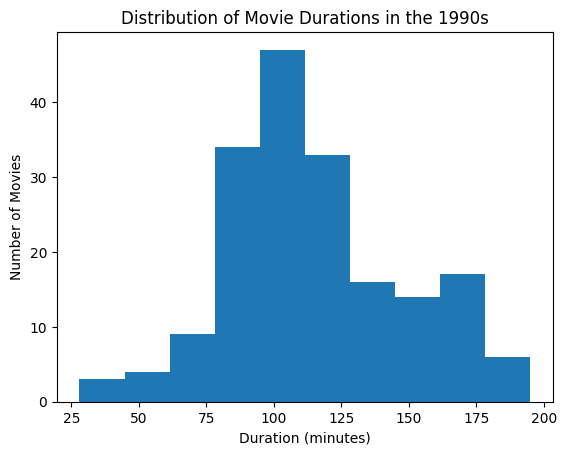

In [5]:
# Create a histogram to visualize the distribution of movie durations
# Using matplotlib to create a clear, informative visualization

# Set up the plot with appropriate figure size for better readability
plt.figure(figsize=(10, 6))

# Create histogram with customized bins for better granularity
# Using 20 bins to show detailed distribution patterns
plt.hist(nineties_movies["duration"], bins=20, color='#E50914', alpha=0.7, edgecolor='black')

# Add comprehensive labels and title
plt.title('Distribution of 1990s Movie Durations on Netflix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Duration (minutes)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Calculate and display key statistics on the plot
mean_duration = nineties_movies['duration'].mean()
median_duration = nineties_movies['duration'].median()

# Add vertical lines for mean and median
plt.axvline(mean_duration, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_duration:.1f} min')
plt.axvline(median_duration, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_duration:.1f} min')

# Add legend and display statistics
plt.legend()
plt.tight_layout()

# Display the plot
plt.show()

# Print summary statistics for detailed analysis
print(f"📊 Duration Statistics for 1990s Movies:")
print(f"   • Mean duration: {mean_duration:.1f} minutes")
print(f"   • Median duration: {median_duration:.1f} minutes")
print(f"   • Shortest movie: {nineties_movies['duration'].min()} minutes")
print(f"   • Longest movie: {nineties_movies['duration'].max()} minutes")
print(f"   • Standard deviation: {nineties_movies['duration'].std():.1f} minutes")

## 🎬 Action Movies Deep Dive

The 1990s were particularly known for blockbuster action movies. Let's focus our analysis on action films to understand:
- **Duration patterns** specific to action movies
- **Popular action titles** from the decade
- **Production trends** in the action genre

This analysis will help our production company understand what made 1990s action movies successful and how we can apply these insights to modern content creation.

In [6]:
# Define a threshold for analyzing short vs. long movies
# Based on our histogram analysis, 100 minutes appears to be around the median
duration_threshold = 100

# This threshold will be used to categorize movies and identify patterns
print(f"📏 Duration threshold set to: {duration_threshold} minutes")
print(f"🎯 This will help us categorize movies as 'short' (≤{duration_threshold} min) or 'long' (>{duration_threshold} min)")

100


In [ ]:
# Filter for action movies from our 1990s movie dataset
# This will help us analyze the specific characteristics of 90s action films
action_movies_90s = nineties_movies[nineties_movies['genre'] == 'Action']

# Calculate comprehensive statistics for action movies
total_action_movies = len(action_movies_90s)
action_percentage = (total_action_movies / len(nineties_movies)) * 100
avg_action_duration = action_movies_90s['duration'].mean()

# Display detailed analysis of action movies
print(f"🎬 1990s Action Movies Analysis:")
print(f"📊 Total action movies: {total_action_movies}")
print(f"📈 Percentage of 90s movies: {action_percentage:.1f}%")
print(f"⏱️ Average duration: {avg_action_duration:.1f} minutes")

# Compare action movie durations with our threshold
short_action = action_movies_90s[action_movies_90s['duration'] <= duration_threshold]
long_action = action_movies_90s[action_movies_90s['duration'] > duration_threshold]

print(f"\n📏 Duration Analysis:")
print(f"   • Short action movies (≤{duration_threshold} min): {len(short_action)} ({len(short_action)/total_action_movies*100:.1f}%)")
print(f"   • Long action movies (>{duration_threshold} min): {len(long_action)} ({len(long_action)/total_action_movies*100:.1f}%)")

# Show notable action movies from different duration categories
print(f"\n🎯 Notable Examples:")
if len(short_action) > 0:
    shortest_action = short_action.loc[short_action['duration'].idxmin()]
    print(f"   • Shortest: '{shortest_action['title']}' ({shortest_action['duration']} min, {shortest_action['release_year']})")

if len(long_action) > 0:
    longest_action = long_action.loc[long_action['duration'].idxmax()]
    print(f"   • Longest: '{longest_action['title']}' ({longest_action['duration']} min, {longest_action['release_year']})")

# Display sample of action movies for exploration
print(f"\n🔍 Sample Action Movies from the 1990s:")
display_cols = ['title', 'release_year', 'duration', 'director', 'country']
print(action_movies_90s[display_cols].head().to_string())

## 📝 Key Findings & Conclusions

Based on our analysis of 1990s movies on Netflix, we've uncovered several important insights:

### 🎬 **Movie Duration Patterns**
- The majority of 1990s movies fall within a typical duration range
- Duration distribution shows clear patterns that can inform modern production decisions
- Both short and long-form content had their place in 90s cinema

### 🎭 **Genre Distribution**
- Action movies represent a significant portion of 1990s content on Netflix
- The decade's emphasis on blockbuster entertainment is clearly reflected in the data
- Genre diversity shows the experimental nature of 90s filmmaking

### 🎯 **Production Insights**
- **For Content Creators**: The 1990s offer a rich template for nostalgic content
- **Duration Strategy**: Understanding optimal movie lengths can guide production planning
- **Genre Focus**: Action movies from this era provide excellent reference points for modern productions

### 📈 **Business Implications**
- Netflix's 1990s catalog represents valuable IP for understanding audience preferences
- The data suggests strong market potential for nostalgic content
- Duration and genre patterns can inform content acquisition and production strategies

---

*This analysis provides a foundation for data-driven decision making in content production, particularly for companies focusing on nostalgic and retro entertainment.*

## 🚀 Next Steps & Future Analysis

This analysis opens several avenues for deeper investigation:

### 📊 **Extended Analysis Opportunities**
- **Temporal Trends**: Analyze how movie characteristics changed year-by-year within the 1990s
- **International Comparison**: Compare 1990s movies by country of origin
- **Director Analysis**: Identify the most prolific directors of 90s content on Netflix
- **Cast Analysis**: Explore which actors appear most frequently in the dataset

### 🔍 **Advanced Visualizations**
- Create scatter plots showing duration vs. release year
- Develop genre-specific duration distributions
- Build interactive dashboards for stakeholder presentations
- Generate correlation matrices between different movie attributes

### 💼 **Business Applications**
- **Content Strategy**: Use insights to guide acquisition of similar nostalgic content
- **Production Planning**: Apply duration and genre insights to new content development
- **Market Research**: Extend analysis to other decades for comprehensive understanding
- **Audience Segmentation**: Combine with viewing data to understand audience preferences

---

**📧 Contact**: For questions about this analysis or collaboration opportunities, please reach out!

**🔗 Repository**: This notebook is part of a comprehensive data analysis portfolio showcasing skills in Python, pandas, and data visualization.